# 02 - Evaluation Pipeline

Drives `scripts/build_mini_testset.py` and `scripts/run_benchmark.py`, runs component diagnostics,
and writes `reports/<name>/report.json` - the same files the **Evaluation Dashboard** reads live
via `src/services/eval_service.py`. Run top-to-bottom; the retrieval step alone lights up the
dashboard. RAGAS / generation steps cost OpenAI credits and are clearly marked.

## 0. Setup

In [1]:
print("hello")

hello


In [2]:
import os, sys, json, subprocess
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
    os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
print('cwd:', ROOT)

import yaml
config = yaml.safe_load(open('configs/config.yaml', encoding='utf-8'))

# Evaluation runs against a collection built from the SAME articles as the test set.
# We do NOT reuse 'newsqa_cnn' here: it was ingested from raw CNN HTML with a different
# chunker + article-id scheme, so its chunk IDs can't match a NewsQA-derived test set
# (retrieval would score 0). Step 1 builds a matched pair with build_mini_testset.py.
COLLECTION = 'newsqa_eval'
DB_PATH    = 'data/chroma_db'
CHUNKS     = f'data/chroma_db/chunks/{COLLECTION}.jsonl'
BM25       = f'data/bm25/{COLLECTION}.pkl'
TESTSET    = 'data/testset_eval.jsonl'
N_ARTICLES = 40           # articles in the eval set
MAX_SCAN   = 2500         # NewsQA rows to stream while grouping
N_EVAL     = 5          # questions per benchmark; raise for a fuller run
PY = sys.executable

cwd: d:\Coding\School\Y3-K3\Text Mining\Text-Mining---NewsQA-RAG


## Data contracts (read before running)

Every hand-off is plain JSON. Full spec + field tables: `docs/evaluation.md` section 6.

**INPUT - test set `data/testset.jsonl`** (one JSON object per line):
```json
{
  "question":           "What was the reported unemployment rate?",
  "ground_truth":       "3.9%",
  "relevant_chunk_ids": ["923426cab4bf_chunk_0"],   // REQUIRED for retrieval metrics
  "article_key":        "cnn/stories/abc123.story", // optional
  "evidence":           "...answer span text...",    // optional
  "article_chunk_ids":  ["923426cab4bf_chunk_0", "..."] // optional
}
```
> `relevant_chunk_ids` is the engineered field. Raw NewsQA has no chunk IDs - a teammate maps answer
> spans to chunk IDs in `src/evaluation/testset.py`. The IDs (`{article_id}_chunk_{i}`) must match the
> `id` values in `data/chroma_db/chunks/*.jsonl` exactly, or retrieval metrics read 0.

**OUTPUT - `reports/<name>/report.json`** (consumed live by the dashboard):
```json
{
  "config":    { "retriever": "hybrid", "n_eval": 100, "timestamp": "..." },
  "retrieval": { "hit_rate@5": 0.82, "mrr@5": 0.71, "recall@5": 0.64, "ndcg@5": 0.69 },
  "qa":        { "exact_match": 0.41, "f1": 0.58 },        // only with --run-generator
  "ragas":     { "faithfulness": 0.90, "context_precision": 0.78 }, // only with --run-ragas
  "failures":  [ { "question": "...", "expected": "...", "retrieved": "...", "reason": "..." } ]
}
```


## 0b. Preflight - what's installed / missing / misconfigured

Run this first. It checks packages, files, and the collection, and validates the test set format
**before** you spend time on a benchmark. Read the checklist; fix any line marked `FAIL`.

In [3]:
import importlib.util, json as _json

def check(label, ok, hint=''):
    mark = 'OK  ' if ok else 'FAIL'
    print(f'[{mark}] {label}' + (f'  -> {hint}' if not ok and hint else ''))
    return ok

print('== packages ==')
for pkg in ['chromadb', 'sentence_transformers', 'tiktoken', 'pandas', 'matplotlib', 'datasets']:
    check(pkg, importlib.util.find_spec(pkg) is not None, f'pip install {pkg}')
check('ragas (optional, step 6)', importlib.util.find_spec('ragas') is not None, 'pip install ragas')

print()
print('== files ==')
check('config: configs/config.yaml', Path('configs/config.yaml').exists())
check(f'chunks: {CHUNKS}', Path(CHUNKS).exists(), 'wrong CHUNKS path? see cell 0')
check(f'bm25 (hybrid only): {BM25}', Path(BM25).exists(), 'wrong BM25 path? or build it first')
has_testset = Path(TESTSET).exists()
check(f'testset: {TESTSET}', has_testset, 'will be built in step 1')

print()
print('== collection ==')
try:
    from src.indexing.embeddings import get_embedding_function
    from src.indexing.chroma_store import ChromaStore
    _stats = ChromaStore(DB_PATH, get_embedding_function(config)).get_collection_stats(COLLECTION)
    check(f"collection '{COLLECTION}' ({_stats.get('count')} chunks)", bool(_stats.get('count')))
except Exception as e:
    check(f"collection '{COLLECTION}'", False, str(e))

print()
print('== testset format ==')
if has_testset:
    row = _json.loads(open(TESTSET, encoding='utf-8').readline())
    required = ['question', 'ground_truth', 'relevant_chunk_ids']
    missing = [f for f in required if f not in row]
    check('required fields present', not missing, f'missing {missing} - see docs/evaluation.md 6.1')
    n_scorable = sum(1 for l in open(TESTSET, encoding='utf-8') if l.strip() and _json.loads(l).get('relevant_chunk_ids'))
    check(f'rows with relevant_chunk_ids ({n_scorable})', n_scorable > 0, 'field must be engineered - retrieval scores 0 without it')
else:
    print('[--  ] skipped (no testset yet)')

== packages ==
[OK  ] chromadb
[OK  ] sentence_transformers
[OK  ] tiktoken
[OK  ] pandas
[OK  ] matplotlib
[OK  ] datasets
[OK  ] ragas (optional, step 6)

== files ==
[OK  ] config: configs/config.yaml
[OK  ] chunks: data/chroma_db/chunks/newsqa_eval.jsonl
[OK  ] bm25 (hybrid only): data/bm25/newsqa_eval.pkl
[OK  ] testset: data/testset_eval.jsonl

== collection ==
[OK  ] collection 'newsqa_eval' (66 chunks)

== testset format ==
[OK  ] required fields present
[OK  ] rows with relevant_chunk_ids (292)


## 1. Build a matched test set + collection (once)
`build_mini_testset.py` selects NewsQA articles, maps evidence to chunk IDs, **and** ingests those
same chunks into the `newsqa_eval` collection - so `relevant_chunk_ids` are guaranteed to exist in
the collection it is scored against. Skips if the test set already exists.

In [4]:
if Path(TESTSET).exists():
    print(f'{TESTSET} exists - skipping build.')
else:
    subprocess.run([PY, 'scripts/build_mini_testset.py',
                    '--n-articles', str(N_ARTICLES),
                    '--max-scan', str(MAX_SCAN),
                    '--output', TESTSET,
                    '--build-collection',
                    '--collection', COLLECTION,
                    '--db-path', DB_PATH], check=True)

data/testset_eval.jsonl exists - skipping build.


## 2. Ingestion / chunking diagnostics  (spec 3.1)
No ground truth needed - pure stats over the chunked collection.

In [5]:
from src.ingestion.chunker import load_chunks
from src.evaluation.metrics import evaluate_chunking, deduplication_rate, semantic_integrity

chunks = load_chunks(CHUNKS)
texts = [c["text"] for c in chunks]

chunking = evaluate_chunking(chunks)
chunking["dedup_rate"]         = deduplication_rate(texts)
chunking["semantic_integrity"] = semantic_integrity(texts)
chunking

d:\Coding\School\Y3-K3\Text Mining\Text-Mining---NewsQA-RAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'total_chunks': 66,
 'mean_tokens': 383.2,
 'std_tokens': 106.4,
 'min_tokens': 61,
 'max_tokens': 486,
 'chunks_per_article_mean': 1.65,
 'chunks_per_article_std': 0.48,
 'dedup_rate': 0.0,
 'semantic_integrity': 0.7121}

## 3. Indexing sanity - Recall@1  (spec 3.2)
Query the vector DB with a sample chunk's own text; it must return at rank 1.

In [6]:
import random
from src.indexing.embeddings import get_embedding_function
from src.indexing.chroma_store import ChromaStore

store = ChromaStore(DB_PATH, get_embedding_function(config))

sample = random.Random(42).sample(chunks, min(50, len(chunks)))
hits = 0
for c in sample:
    res = store.query(COLLECTION, query_texts=[c["text"]], n_results=1)
    if res["ids"][0] and res["ids"][0][0] == c["id"]:
        hits += 1
print(f"Sanity Recall@1: {hits}/{len(sample)} = {hits/len(sample):.3f}")
print("Collection count:", store.get_collection_stats(COLLECTION).get("count"))

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12411.32it/s]


Sanity Recall@1: 50/50 = 1.000
Collection count: 66


## 4. Retrieval benchmark - dense vs hybrid  (spec 3.3 / 3.4)
Calls `run_benchmark.py` per retriever. Retrieval-only = **no API cost**. Writes `reports/<name>/report.json`.

In [7]:
def bench(name, retriever, extra=None):
    # '-u' + streaming Popen so progress prints appear live (subprocess.run buffers until done)
    cmd = [PY, '-u', 'scripts/run_benchmark.py',
           '--retriever', retriever,
           '--testset', TESTSET,
           '--n-eval', str(N_EVAL),
           '--db-path', DB_PATH,
           '--collection', COLLECTION,
           '--report-dir', f'reports/{name}'] + (extra or [])
    print('>', ' '.join(cmd))
    proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                            text=True, bufsize=1)
    for line in proc.stdout:
        print(line, end='')
    if proc.wait() != 0:
        raise RuntimeError(f'{name} benchmark failed (see output above)')

bench('dense',  'dense')
bench('hybrid', 'hybrid', ['--chunks-path', CHUNKS, '--bm25-path', BM25])

> d:\Coding\School\Y3-K3\Text Mining\Text-Mining---NewsQA-RAG\.venv\Scripts\python.exe -u scripts/run_benchmark.py --retriever dense --testset data/testset_eval.jsonl --n-eval 5 --db-path data/chroma_db --collection newsqa_eval --report-dir reports/dense
Loading test set from data/testset_eval.jsonl ...
  Total entries    : 292
  With ground truth: 292
  Evaluating       : 5

Setting up retriever: dense ...

Running evaluation on 5 questions ...

Loading weights: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 103/103 [00:00<00:00, 8735.48it/s]

Computing metrics ...

Report saved to reports/dense\report.json
Summary  saved to reports/dense\report_summary.txt

=== Summary ===
  hit_rate@5=0.8  mrr@5=0.65  recall@5=0.8  ndcg@5=0.6861
> d:\Coding\School\Y3-K3\Text Mining\Text-Mining---NewsQA-RAG\.venv\Scripts\python.exe -u scripts/run_benchmark.py --retriever hybrid --testset data/testset_eval.jsonl --n-eval 5 --db-path data/chroma_db --collection newsqa_eval --report-dir reports/hybrid --chunks-pa

## 5. Compare + plot
Charts dense vs hybrid - mirrors the dashboard's bar chart.

,dense,hybrid
hit_rate@1,0.6000,0.8
mrr@1,0.6000,0.8
recall@1,0.6000,0.8
ndcg@1,0.6000,0.8
hit_rate@3,0.6000,0.8
mrr@3,0.6000,0.8
recall@3,0.6000,0.8
ndcg@3,0.6000,0.8
hit_rate@5,0.8000,0.8
mrr@5,0.6500,0.8


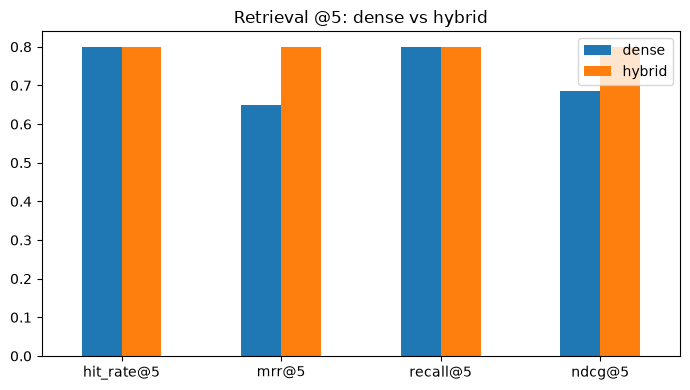

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

def load(name): return json.load(open(f"reports/{name}/report.json", encoding="utf-8"))
dense, hybrid = load("dense"), load("hybrid")

df = pd.DataFrame({"dense": dense["retrieval"], "hybrid": hybrid["retrieval"]})
display(df)

keys = [f"{m}@5" for m in ("hit_rate", "mrr", "recall", "ndcg")]
df.loc[keys].plot.bar(figsize=(7,4), title="Retrieval @5: dense vs hybrid", rot=0)
plt.tight_layout(); plt.show()

## 5b. Ước lượng số request LLM trước khi chạy cell 6
RAGAS nhân số call (nhất là `context_precision` ~1 call/đoạn context). Ước lượng trước khi tốn tiền.

In [9]:
import json as _json
if not Path(TESTSET).exists():
    print('Chưa có', TESTSET, '- chạy cell Step 1 trước.')
else:
    rows = [_json.loads(l) for l in open(TESTSET, encoding='utf-8') if l.strip()]
    n_scorable = sum(1 for r in rows if r.get('relevant_chunk_ids'))
    n_q = min(N_EVAL, n_scorable)
    rtn = config.get('retrieval', {}).get('reranker', {}).get('top_n', 5)
    rm = config.get('evaluation', {}).get('metrics',
        ['faithfulness', 'answer_relevancy', 'context_precision', 'context_recall'])
    factor = {'faithfulness': 2, 'answer_relevancy': 1, 'context_precision': rtn, 'context_recall': 1}
    per_q = {'generation': 1}
    per_q.update({m: factor.get(m, 1) for m in rm})
    tpq = sum(per_q.values())
    print(f'Câu hỏi có ground-truth : {n_scorable}')
    print(f'Sẽ chạy (N_EVAL cap)    : {n_q}')
    print(f'~request LLM / câu      : {tpq}  ->  {per_q}')
    print(f'=> TỔNG ước lượng       : ~{n_q * tpq} request  (xấp xỉ)')
    print('Giảm: bỏ context_precision khỏi config, hạ reranker.top_n, hoặc hạ N_EVAL.')

Câu hỏi có ground-truth : 292
Sẽ chạy (N_EVAL cap)    : 5
~request LLM / câu      : 10  ->  {'generation': 1, 'faithfulness': 2, 'answer_relevancy': 1, 'context_precision': 5, 'context_recall': 1}
=> TỔNG ước lượng       : ~50 request  (xấp xỉ)
Giảm: bỏ context_precision khỏi config, hạ reranker.top_n, hoặc hạ N_EVAL.


## 6. Full pipeline + RAGAS  (generation + LLM-judge metrics)
Adds generation (EM/F1) and RAGAS metrics to the **hybrid** report so the dashboard cards fill in.
Uses **DeepSeek** for both when `DEEPSEEK_API_KEY` is in `.env` (cheap; embeddings local/free); falls
back to OpenAI otherwise. Run cell 5b first to estimate the request count.

In [10]:
# Uncomment to run (spends money):
bench("hybrid", "hybrid",
      ["--chunks-path", CHUNKS, "--bm25-path", BM25, "--run-generator", "--run-ragas"])
json.load(open("reports/hybrid/report.json", encoding="utf-8"))

> d:\Coding\School\Y3-K3\Text Mining\Text-Mining---NewsQA-RAG\.venv\Scripts\python.exe -u scripts/run_benchmark.py --retriever hybrid --testset data/testset_eval.jsonl --n-eval 5 --db-path data/chroma_db --collection newsqa_eval --report-dir reports/hybrid --chunks-path data/chroma_db/chunks/newsqa_eval.jsonl --bm25-path data/bm25/newsqa_eval.pkl --run-generator --run-ragas
Loading test set from data/testset_eval.jsonl ...
  Total entries    : 292
  With ground truth: 292
  Evaluating       : 5

Setting up retriever: hybrid ...
Loading chunks from data/chroma_db/chunks/newsqa_eval.jsonl ...
Loading BM25 index from data/bm25/newsqa_eval.pkl...

Running evaluation on 5 questions ...

Loading weights: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 103/103 [00:00<00:00, 11478.42it/s]

Computing metrics ...
Running RAGAS judge on 5 samples (LLM calls, this can take a while) ...
d:\Coding\School\Y3-K3\Text Mining\Text-Mining---NewsQA-RAG\src\evaluation\metrics.py:237: LangChainDeprecationWarning: The 

{'config': {'retriever': 'hybrid',
  'reranker': 'noop',
  'top_k': 10,
  'rerank_top_n': 5,
  'collection': 'newsqa_eval',
  'embedding': {'provider': 'sentence-transformers',
   'model_name': 'all-MiniLM-L6-v2',
   'dimensions': 384},
  'chunking': {'strategy': 'recursive',
   'chunk_size': 512,
   'chunk_overlap': 64,
   'sentences_per_chunk': 8,
   'sentence_overlap': 2},
  'run_generator': True,
  'run_ragas': True,
  'n_eval': 5,
  'timestamp': '2026-07-13T13:49:57.599524'},
 'retrieval': {'hit_rate@1': 0.8,
  'mrr@1': 0.8,
  'recall@1': 0.8,
  'ndcg@1': 0.8,
  'hit_rate@3': 0.8,
  'mrr@3': 0.8,
  'recall@3': 0.8,
  'ndcg@3': 0.8,
  'hit_rate@5': 0.8,
  'mrr@5': 0.8,
  'recall@5': 0.8,
  'ndcg@5': 0.8,
  'hit_rate@10': 0.8,
  'mrr@10': 0.8,
  'recall@10': 0.8,
  'ndcg@10': 0.8,
  'n_samples': 5},
 'qa': {'exact_match': 0.0, 'f1': 0.1692, 'n_samples': 5},
 'ragas': {'faithfulness': 0.8,
  'answer_relevancy': 0.711,
  'context_precision': 0.8,
  'context_recall': 0.8},
 'failures':

## Done -> dashboard is live
`reports/*/report.json` now feed the Evaluation Dashboard automatically:
```bash
uvicorn api.main:app --reload      # backend reads reports/ via eval_service
cd ui && npm run dev               # open the Evaluation Dashboard (admin)
```
Re-run this notebook anytime to refresh the numbers.